In [25]:
#lab 03
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

In [26]:
data=pd.read_csv("data.csv",  encoding='cp1252')
data.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


**Task 1**

In [34]:
#total monthly sales summarized by month
data["Order Date"]=pd.to_datetime(data["Order Date"])
data["Year"]=data["Order Date"].dt.year
data["Month"]=data["Order Date"].dt.month
data.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10


In [45]:
#now we plot for a certain year
#imma plot for 2016
yof=2016 #year of focus

In [80]:
#bar chart
sns.set_theme(style="darkgrid")
year_data=data[data["Year"]==yof]
#print(year_data.head(5))
#sum the sales of all months so that each month only has one row

year_data=year_data.groupby(["Month"])[["Sales", "Profit"]].sum()
year_data=year_data.reset_index()
year_data=pd.DataFrame(year_data)

#match month number to month name
year_data.head(12)
year_data["Month"] = year_data["Month"].apply(lambda x: calendar.month_name[int(x)])

print(year_data.head(12))

        Month       Sales      Profit
0     January  18542.4910   2824.8233
1    February  22978.8150   5004.5795
2       March  51715.8750   3611.9680
3       April  38750.0390   2977.8149
4         May  56987.7280   8662.1464
5        June  40344.5340   4750.3781
6        July  39261.9630   4432.8779
7      August  31115.3743   2062.0693
8   September  73410.0249   9328.6576
9     October  59687.7450  16243.1425
10   November  79411.9658   4011.4075
11   December  96999.0430  17885.3093


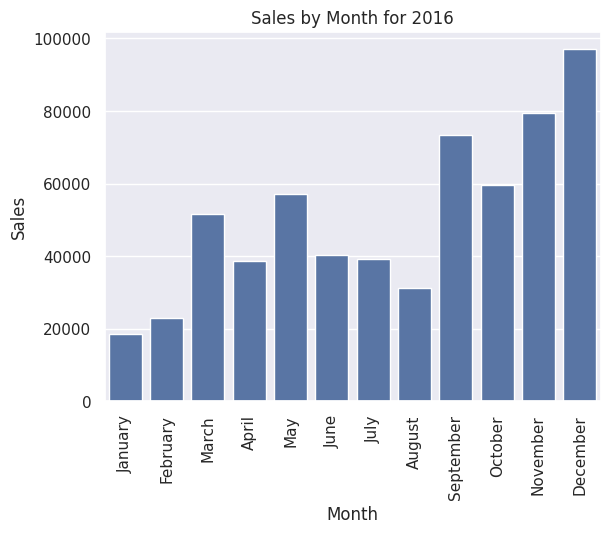

In [47]:
sns.barplot(data=year_data, x=year_data["Month"], y=year_data["Sales"])
plt.xlabel("Month")
plt.ylabel("Sales")
plt.title(f"Sales by Month for {yof}")
plt.xticks(rotation=90)
plt.show()

Text(0.5, 1.0, 'Sales by Month for 2016')

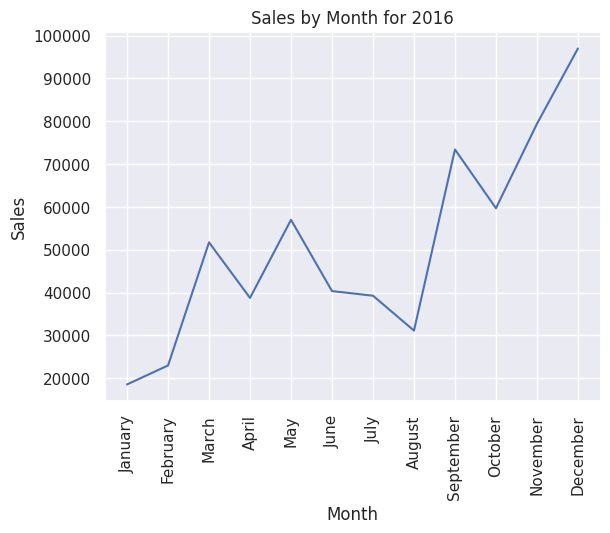

In [51]:
#line chart
sns.lineplot(data=year_data, x=year_data["Month"], y=year_data["Sales"])
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=90)
plt.title(f"Sales by Month for {yof}")

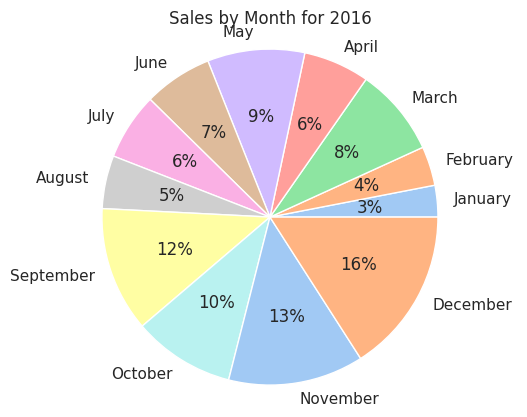

In [58]:
#pie chart
colors = sns.color_palette("pastel")
plt.pie(year_data["Sales"], labels=year_data["Month"], colors=colors, autopct="%.0f%%")
plt.axis("equal")
plt.title(f"Sales by Month for {yof}")
plt.show()

The graph that shows it the best is the bar chart which neatly categorizesit by month and helps see the total sales for each month, the line chart is decent if we want to see the trend in sales with respect to time, the one that hides it the most is the pie-chart, which uses angles which without the percentages do not easily communicate the differnces in each month, because as humans we cant easily see the difference in angles if they are not stark.

**Task 2**

                   Sales      Profit
Sub-Category                        
Phones        330007.054  44515.7306
Chairs        328449.103  26590.1663
Storage       223843.608  21278.8264
Tables        206965.532 -17725.4811
Binders       203412.733  30221.7633


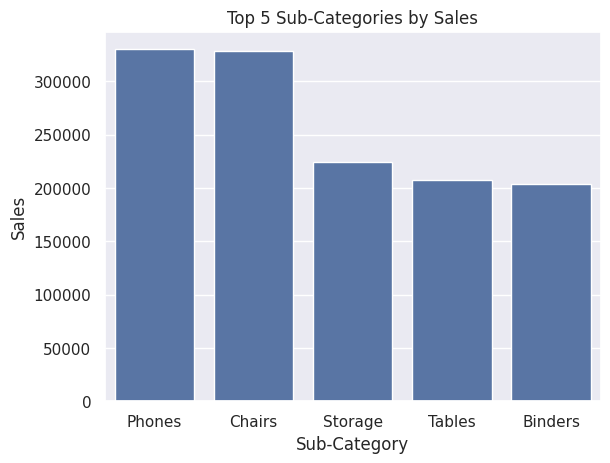

In [77]:
#"Compare total sales across the top 5 sub-categories."
data.groupby("Sub-Category")["Sales"].sum()
#now we get top 5 sub categories
top_5=data.groupby("Sub-Category")[["Sales", "Profit"]].sum()
top_5=pd.DataFrame(top_5)
top_5=top_5.sort_values(by="Sales", ascending=False)
print(top_5.head(5))
sns.barplot(data=top_5.head(5), x=top_5.head(5).index, y=top_5.head(5)["Sales"])
plt.title("Top 5 Sub-Categories by Sales")
plt.xlabel("Sub-Category")
plt.ylabel("Sales")
plt.show()

Here the strongest choice would be bar plot, because we want to study categories, the weaker choice which could be considered is maybe like pie chart because understanding the total unit of sales would be a headavhe to capture just from angles.

Text(0.5, 1.0, 'Sales by Month for 2016')

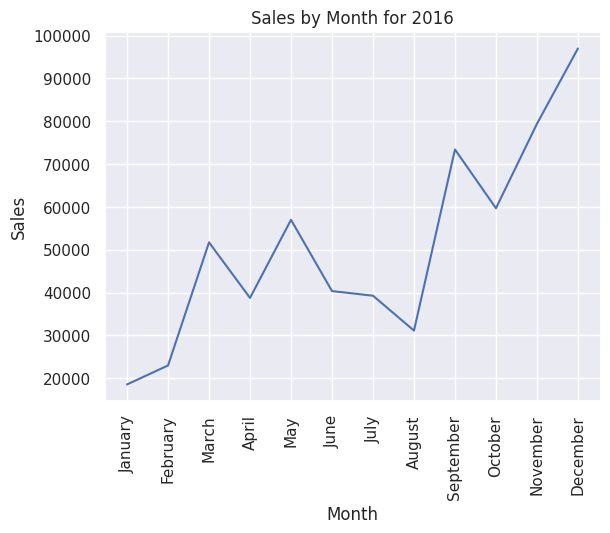

In [66]:
#"Show the revenue trend over time." (Reuse the monthly sales data from Task 1.)
sns.lineplot(data=year_data, x=year_data["Month"], y=year_data["Sales"])
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=90)
plt.title(f"Sales by Month for {yof}")

The best choice would be line chart because we want to understand the trend/patterns, the ups and downs in the line chart make it easy to see which months performed good and which we performed poorly, a weaker choice that could be considered is bar chart, though bar chart would also accurately represent sales, but it does not visualise the monthly trends.

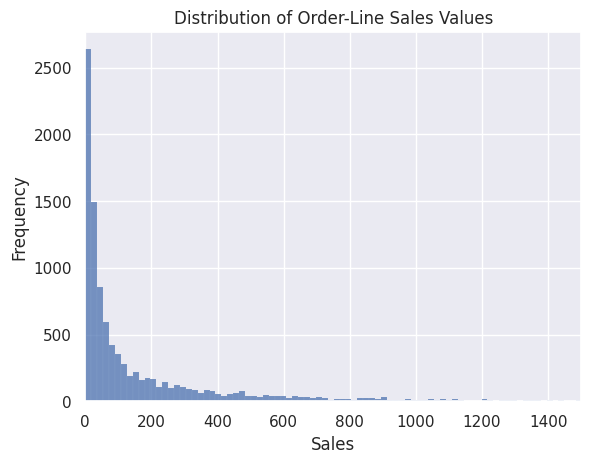

In [72]:
#"Show the distribution of order-line sales values." (Use the raw sales column
#directly — no summarizing needed.)
sns.histplot(data=data, x="Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.title("Distribution of Order-Line Sales Values")
plt.xlim(0, 1500)
plt.show()

For distributions we use histograms, because histograms allows continous intervals, but a count plot would need categories, which makes no sense for making categories for sales.

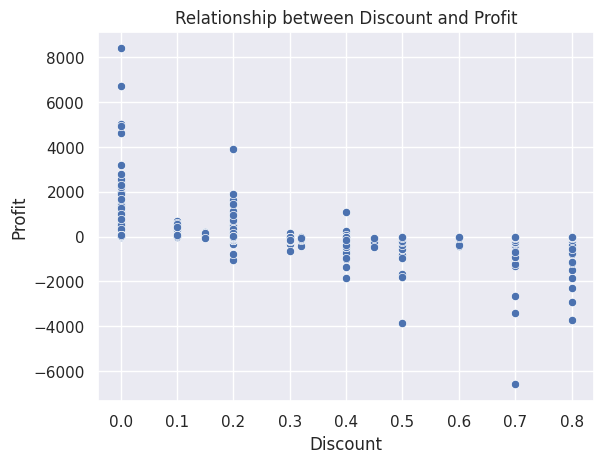

In [73]:
#"Show the relationship between discount level and profit." (Use the raw discount
#and profit columns directly — no summarizing needed.)
sns.scatterplot(data=data, x="Discount", y="Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Relationship between Discount and Profit")
plt.show()

Here the best choice is scatter, because we want to see the potential relationship between x and y values, the weaker choice is line becase lowkey joining these points would be kinda crazy ngl

**Task 3**

In [92]:
#total sales by region
sales_by_region=data.groupby("Region")["Sales"].sum()
sales_by_region=pd.DataFrame(sales_by_region)
print(sales_by_region)
#total sales by region and category
sales_by_region_category=data.groupby(["Region", "Category"])["Sales"].sum().unstack()
sales_by_region_category=pd.DataFrame(sales_by_region_category)
print(sales_by_region_category)
#total profit by monyh
#print(year_data)
profit_by_month=year_data.groupby("Month")["Profit"].sum()
profit_by_month=pd.DataFrame(profit_by_month)
print(profit_by_month)

               Sales
Region              
Central  501239.8908
East     678781.2400
South    391721.9050
West     725457.8245
Category    Furniture  Office Supplies  Technology
Region                                            
Central   163797.1638       167026.415  170416.312
East      208291.2040       205516.055  264973.981
South     117298.6840       125651.313  148771.908
West      252612.7435       220853.249  251991.832
               Profit
Month                
April       2977.8149
August      2062.0693
December   17885.3093
February    5004.5795
January     2824.8233
July        4432.8779
June        4750.3781
March       3611.9680
May         8662.1464
November    4011.4075
October    16243.1425
September   9328.6576


/tmp/ipykernel_2388/210604908.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sales_by_region, x=sales_by_region.index, y=sales_by_region["Sales"], palette=["#63d95b", "#FFD166", "#353adb", "#db4744" ])


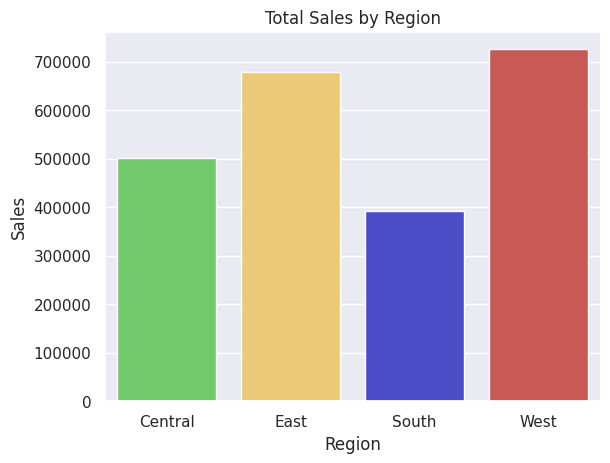

In [90]:
#Recolor the region sales chart with a proper categorical palette.
sns.barplot(data=sales_by_region, x=sales_by_region.index, y=sales_by_region["Sales"], palette=["#63d95b", "#FFD166", "#353adb", "#db4744" ])
plt.xlabel("Region")
plt.ylabel("Sales")
plt.title("Total Sales by Region")
plt.show()

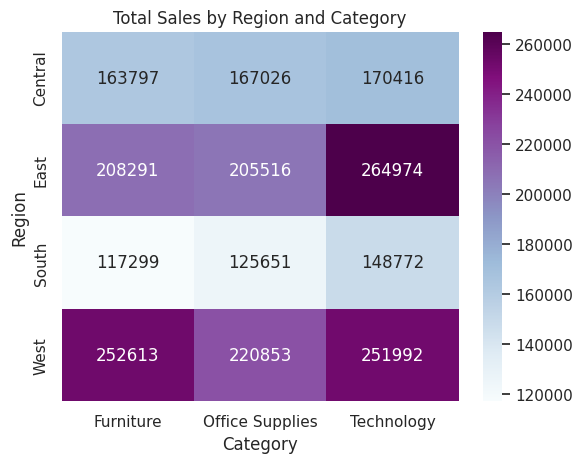

In [95]:
#(b) Recolor the region-by-category data as a heatmap using a sequential palette.
sns.heatmap(data=sales_by_region_category, cmap="BuPu", annot=True, fmt=".0f")
plt.title("Total Sales by Region and Category")
plt.show()


/tmp/ipykernel_2388/2032448646.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=profit_by_month, x=profit_by_month.index, y=profit_by_month["Profit"], palette="RdBu")


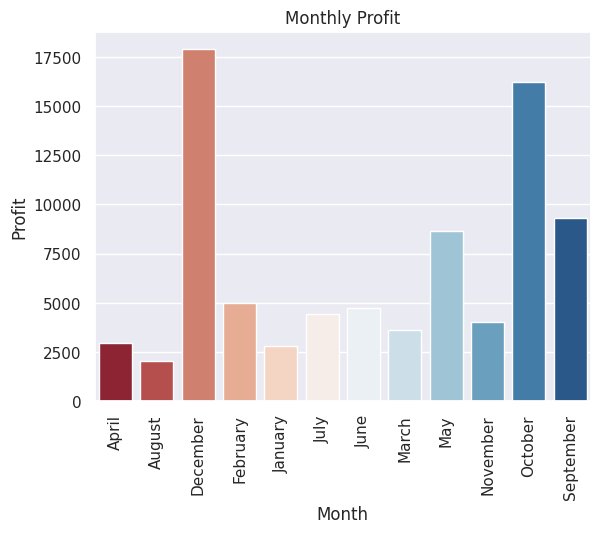

In [97]:
#(c) Build a diverging-color chart of monthly profit, since it crosses zero.
sns.barplot(data=profit_by_month, x=profit_by_month.index, y=profit_by_month["Profit"], palette="RdBu")
plt.xlabel("Month")
plt.xticks(rotation=90)
plt.ylabel("Profit")
plt.title("Monthly Profit")
plt.show()

**Task 4**

In [98]:
#Write a function that computes the WCAG contrast ratio between two RGB colors,
#and test it against the colors used in Task 3
def relative_luminance(color):
    """Calculates the relative luminance of an RGB color tuple (0-255)."""
    rgb = []
    for channel in color:
        # Normalize the 8-bit channel to a 0.0-1.0 range
        c = channel / 255.0
        # Linearize the sRGB channel value according to WCAG 2.x formulas
        if c <= 0.03928:
            rgb.append(c / 12.92)
        else:
            rgb.append(((c + 0.055) / 1.055) ** 2.4)

    # Apply standard coefficients for human perception of RGB wavelengths
    return 0.2126 * rgb[0] + 0.7152 * rgb[1] + 0.0722 * rgb[2]


def wcag_contrast(color1, color2):
    """Computes the WCAG contrast ratio between two RGB tuple colors."""
    l1 = relative_luminance(color1)
    l2 = relative_luminance(color2)

    # Ensure l1 represents the lighter luminance and l2 represents the darker luminance
    lighter = max(l1, l2)
    darker = min(l1, l2)

    # Calculate and return the ratio
    return (lighter + 0.05) / (darker + 0.05)

The contrast ratio is 21.00:1


In [104]:
def hex_to_rgb(hex_str):
    """Converts a HEX color string (e.g., '#63d95b') to an RGB tuple (0-255)."""
    hex_str = hex_str.lstrip("#")
    return tuple(int(hex_str[i:i + 2], 16) for i in (0, 2, 4))


def relative_luminance(color):
    """Calculates the relative luminance of an RGB color tuple (0-255)."""
    # Accept both HEX strings and RGB tuples
    if isinstance(color, str):
        color = hex_to_rgb(color)

    rgb = []
    for channel in color:
        c = channel / 255.0
        if c <= 0.03928:
            rgb.append(c / 12.92)
        else:
            rgb.append(((c + 0.055) / 1.055) ** 2.4)

    return 0.2126 * rgb[0] + 0.7152 * rgb[1] + 0.0722 * rgb[2]


def wcag_contrast(color1, color2):
    """Computes the WCAG contrast ratio between two colors (HEX or RGB)."""
    l1 = relative_luminance(color1)
    l2 = relative_luminance(color2)

    lighter = max(l1, l2)
    darker = min(l1, l2)

    return (lighter + 0.05) / (darker + 0.05)


# Test with your palette and check compliance (4.5:1 for normal text)
palette = ["#63d95b", "#FFD166", "#353adb", "#db4744"]

print(f"{'Color 1':<10} {'Color 2':<10} {'Ratio':<10} {'WCAG AA (Text)'}")
print("-" * 45)

for i, color1 in enumerate(palette):
    for color2 in palette[i + 1:]:  # Prevents duplicate pairs and self-comparison
        ratio = wcag_contrast(color1, color2)
        passes = "PASS" if ratio >= 4.5 else "FAIL"
        print(f"{color1:<10} {color2:<10} {ratio:<10.2f} {passes}")

Color 1    Color 2    Ratio      WCAG AA (Text)
---------------------------------------------
#63d95b    #FFD166    1.25       FAIL
#63d95b    #353adb    4.18       FAIL
#63d95b    #db4744    2.32       FAIL
#FFD166    #353adb    5.24       PASS
#FFD166    #db4744    2.91       FAIL
#353adb    #db4744    1.80       FAIL


In [105]:
profit_by_subcategory=data.groupby("Sub-Category")["Profit"].sum()
profit_by_subcategory=pd.DataFrame(profit_by_subcategory)
print(profit_by_subcategory)

                  Profit
Sub-Category            
Accessories   41936.6357
Appliances    18138.0054
Art            6527.7870
Binders       30221.7633
Bookcases     -3472.5560
Chairs        26590.1663
Copiers       55617.8249
Envelopes      6964.1767
Fasteners       949.5182
Furnishings   13059.1436
Labels         5546.2540
Machines       3384.7569
Paper         34053.5693
Phones        44515.7306
Storage       21278.8264
Supplies      -1189.0995
Tables       -17725.4811


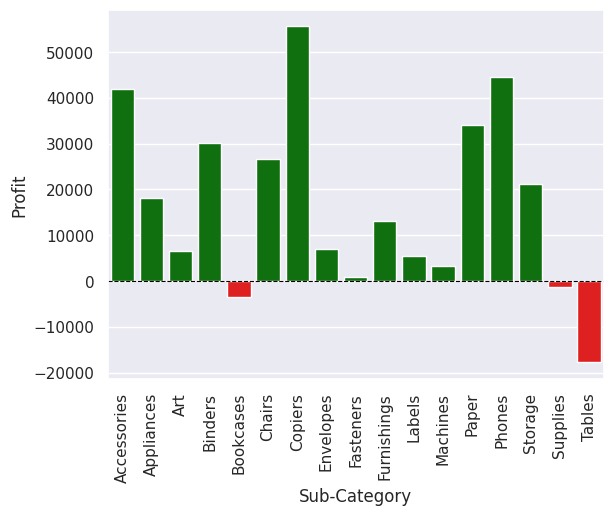

In [111]:
#Build a chart that encodes loss vs. gain
#using red and green only.
#those negative-> red
#else green
palette_colors = [
    "red" if val < 0 else "green" for val in profit_by_subcategory["Profit"]
]
sns.barplot(
    data=profit_by_subcategory,
    x=profit_by_subcategory.index,
    y="Profit",
    hue=profit_by_subcategory.index,
    palette=palette_colors,
    legend=False,
)
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.xticks(rotation=90)
plt.show()

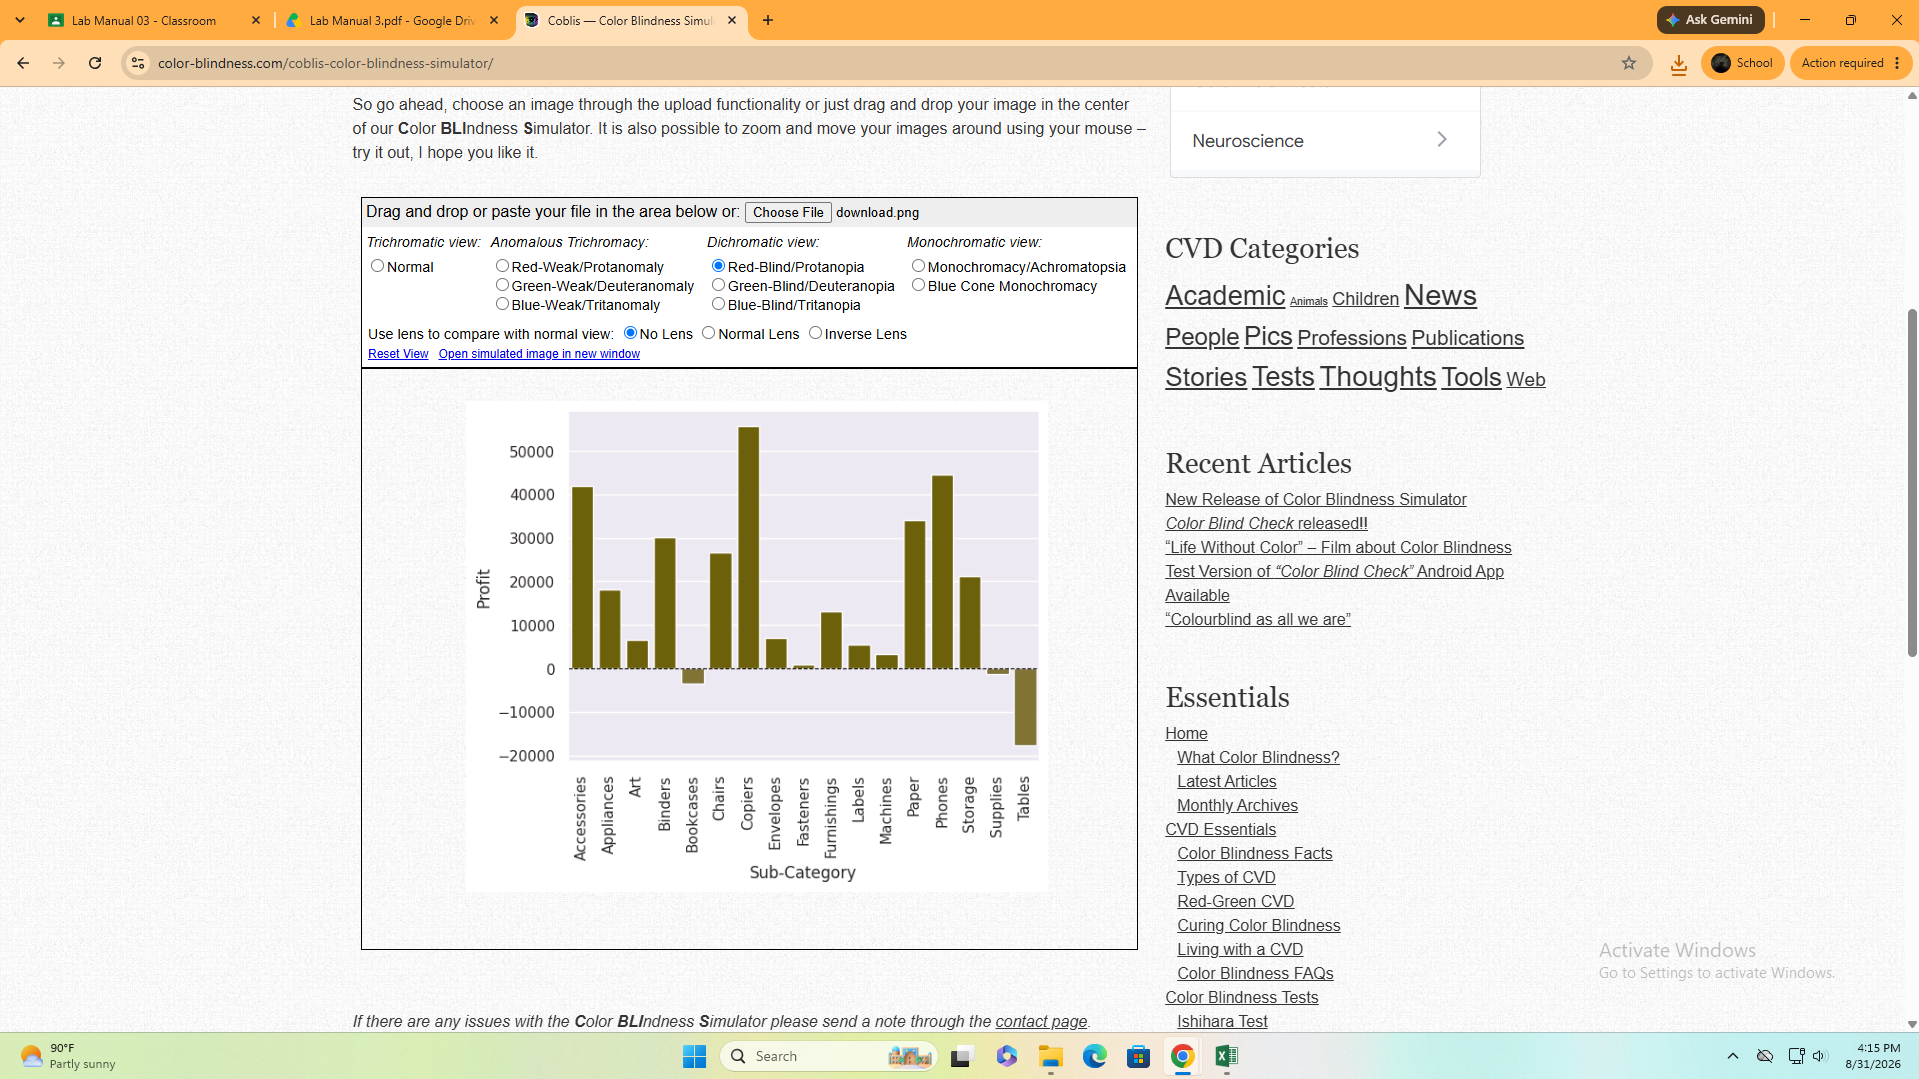

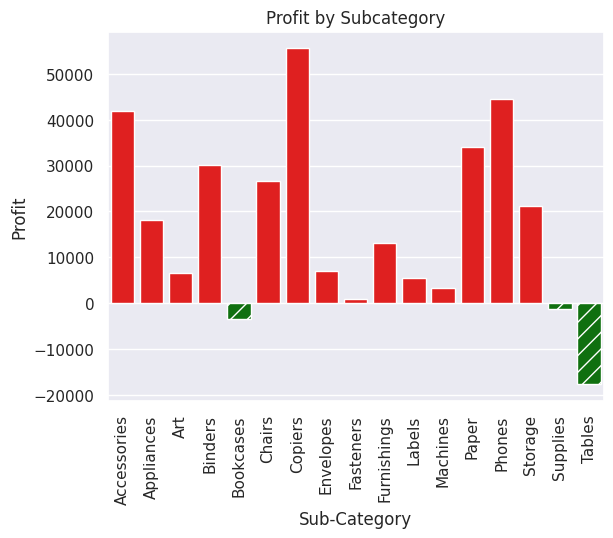

In [146]:

ax = sns.barplot(
    data=profit_by_subcategory,
    x=profit_by_subcategory.index,
    y="Profit",
    hue=profit_by_subcategory.index,
    palette=palette_colors,
    legend=False,
)

# Apply diagonal hatching specifically to negative bars
for patch in ax.patches:
    if patch.get_height() < 0:
        patch.set_hatch("//")
plt.xticks(rotation=90)
plt.title("Profit by Subcategory")
plt.show()

**Task 5**

/tmp/ipykernel_2388/3842078070.py:2: UserWarning: The palette list has more values (17) than needed (4), which may not be intended.
  sns.barplot(


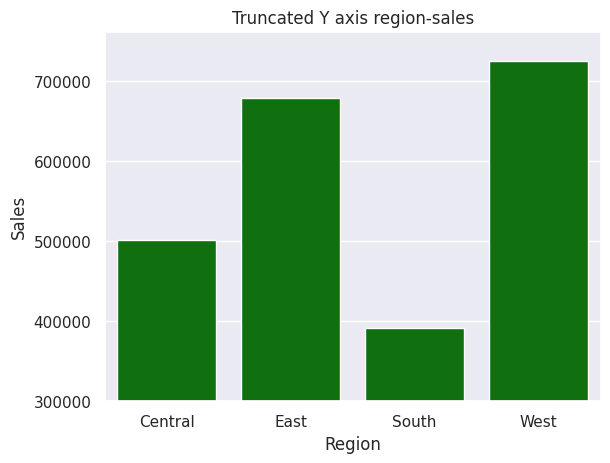

In [117]:
#A truncated y-axis on the region sales chart
sns.barplot(
    data=sales_by_region,
    x="Region",
    y="Sales",
    hue="Region",
    palette=palette_colors,
    legend=False,
)
plt.ylim(300000)
plt.title("Truncated Y axis region-sales")
plt.show()

Messes up the actual difference between two regions' sales, and like it dramatacizes difference.

<Axes: xlabel='Category', ylabel='Quantity'>

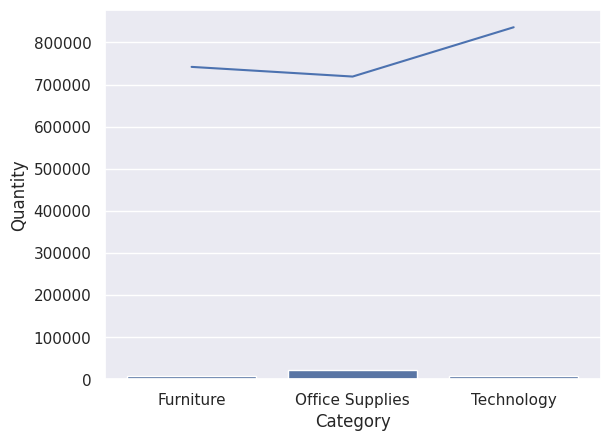

In [127]:
#A dual-axis chart overlaying two unrelated measures to imply a fake
#correlation
#like idk quantity per category and sales per category
quantity_per_category=data.groupby("Category")["Quantity"].sum()
quantity_per_category=pd.DataFrame(quantity_per_category)
sales_per_category=data.groupby("Category")["Sales"].sum()
sales_per_category=pd.DataFrame(sales_per_category)
#now we make a dual axis chart to show a fake ahh relationship
#bar chart for quantity
#line chart for sales
sns.barplot(data=quantity_per_category, x="Category", y="Quantity")
sns.lineplot(data=sales_per_category, x="Category", y="Sales")


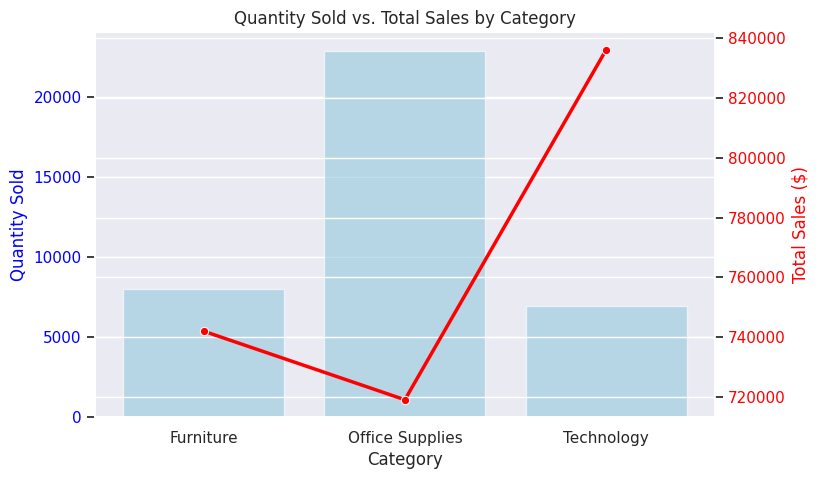

In [132]:

quantity_per_category = data.groupby("Category")["Quantity"].sum().reset_index()
sales_per_category = data.groupby("Category")["Sales"].sum().reset_index()
fig, ax1 = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=quantity_per_category,
    x="Category",
    y="Quantity",
    ax=ax1,
    color="skyblue",
    alpha=0.6,
)
ax1.set_ylabel("Quantity Sold", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
ax2 = ax1.twinx()
sns.lineplot(
    data=sales_per_category,
    x="Category",
    y="Sales",
    ax=ax2,
    color="red",
    marker="o",
    linewidth=2.5,
)
ax2.set_ylabel("Total Sales ($)", color="red")
ax2.tick_params(axis="y", labelcolor="red")

plt.title("Quantity Sold vs. Total Sales by Category")
plt.show()

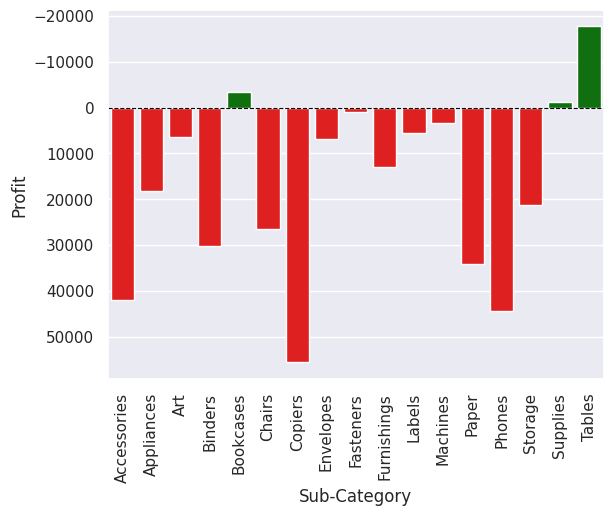

In [131]:
#Build a chart that encodes loss vs. gain
#using red and green only.
#those negative-> red
#else green
palette_colors = [
    "green" if val < 0 else "red" for val in profit_by_subcategory["Profit"]
]
ax= sns.barplot(
    data=profit_by_subcategory,
    x=profit_by_subcategory.index,
    y="Profit",
    hue=profit_by_subcategory.index,
    palette=palette_colors,
    legend=False,
)
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.xticks(rotation=90)
ax.invert_yaxis()
plt.show()

**Task 6**

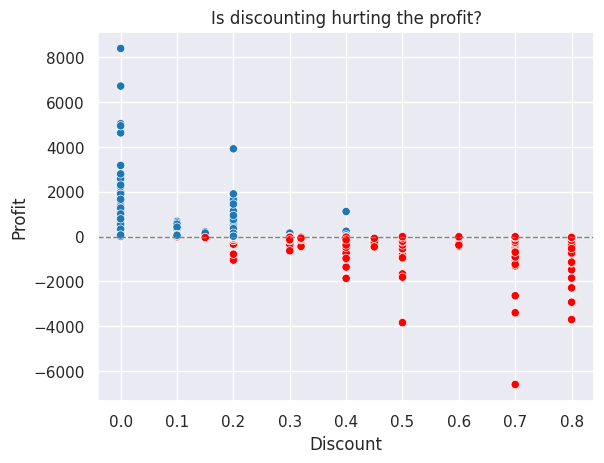

In [135]:
#is discounting hurting the profit
#we would need to study the discounts applied and sales
#SCATTER
#to make it accessinle we can make the negative balls have some pattern or somehtng idk
colors = ["red" if p < 0 else "#1f77b4" for p in data["Profit"]]
sns.scatterplot(data=data, x="Discount", y="Profit", c=colors)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Is discounting hurting the profit?")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

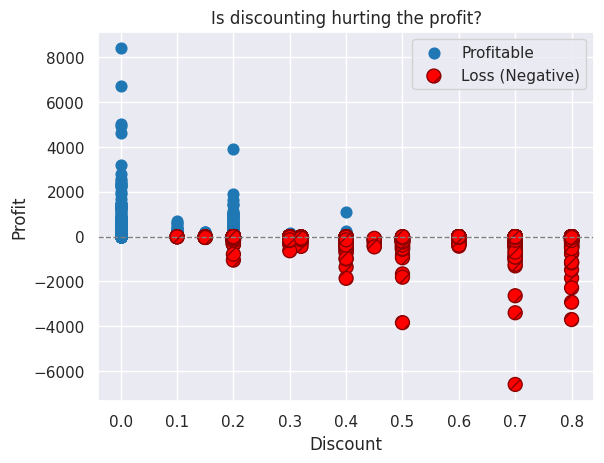

In [147]:

# Separate positive and negative data
pos_data = data[data["Profit"] >= 0]
neg_data = data[data["Profit"] < 0]
# Plot positive points (solid blue fill)
plt.scatter(
    pos_data["Discount"],
    pos_data["Profit"],
    color="#1f77b4",
    label="Profitable",
    s=60
)
# Plot negative points (red fill with hatching for accessibility)
plt.scatter(
    neg_data["Discount"],
    neg_data["Profit"],
    color="red",
    edgecolor="darkred",
    hatch="//",
    label="Loss (Negative)",
    s=100                  # Slightly larger size to make hatching clear
)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Is discounting hurting the profit?")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.legend()
plt.show()

I chose scatter plot bcause yall wanted to see how one variable ffects the other, so to study correltaion between two variables i used scatter plot.

to mislead someone on the effect of discount on profit we can limit the profit generated to show an overlyy postive picutre

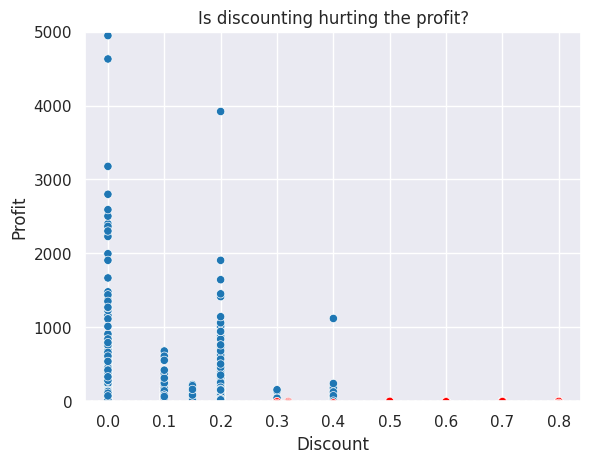

In [137]:

colors = ["red" if p < 0 else "#1f77b4" for p in data["Profit"]]
sns.scatterplot(data=data, x="Discount", y="Profit", c=colors)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Is discounting hurting the profit?")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.ylim(0, 5000)
plt.show()

CHART TYE IS SCATTER AS EXPLAINED ABOVE, COLOR CHOICE IS RED FOR NEFGATIVES AND GREEN FOR POSITIVE,S AND ACCESSBILITY CHECK IS THAT WE APPLIED A HATCHED FOR THE NEGATIVE ONES.